# 非线性系统最优控制--目标函数不可导的情况

本文档关注非线性系统的最优控制计算问题。我们考虑线性系统：
\begin{align*}
    & \dot{x}(t)=f\bigl(x(t),u(t)\bigr), \qquad x(0)=x_0 \in \mathcal{X}_0 \subseteq \mathbb{R}^n \\
    & J(x_0, u)=\int_0^T \ell\bigl(x(t),u(t)\bigr)\,d t+\Phi\bigl(x(T)\bigr).
\end{align*}
根据课程讲义，当我们利用神经网络$\pi_{\theta}(t,x)$来表征系统输入$u(t,x)$时，最优控制问题可以写为
\begin{align*}
    J^\text{tot}(\theta) = \mathbb{E}_{x_0\sim U(\mathcal X_0)}\left[ \tilde J(x_0, \theta)\right] 
\end{align*}
其中$\tilde J(x_0, \theta) \triangleq \int_0^T \ell\bigl(x(t),\pi_{\theta}(t,x(t))\bigr)\,d t+\Phi\bigl(x(T)\bigr)$。

为了说明方法，以及确认得到结果的最优性。我们依然用一个线性系统作为例子展示，但我们将它写成一般的形式，即我们设置
\begin{align*}
    f(x,u) = Ax+Bu, && \ell(x,u)= \bigl(x^\top Qx+u^\top Ru\bigr),
    && \Phi\bigl(x\bigr) = x^\top F x
\end{align*}
我们依旧选取：
\begin{align*}
&A = \begin{bmatrix} -0.7 & 0.5 \\ 1 & -1.5 \end{bmatrix},
&& B = \begin{bmatrix} 1 \\ 0.5 \end{bmatrix},
&& Q = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix},
&& R = \begin{bmatrix} 1 \end{bmatrix},\\
& F = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix},
&& x_0 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}.
&& T = 10
\end{align*}
初始点落在$\mathcal X_0$区域$[1,2]\times[1,2]$上。

In [1]:
# Required packages for this notebook: torch, matplotlib
# If needed, install them with: pip install torch matplotlib

import time
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
})

In [3]:
T = 10
dt = 0.01
x0 = torch.tensor([[[1.], [1.]]])  # (batch_size, state_dim, 1)
A = torch.tensor([[-0.7, 0.5], [1., -1.5]])
B = torch.tensor([[1.], [0.5]])
Q = torch.eye(2)
R = torch.eye(1)
F = torch.tensor([[1., 0.], [0., 1.]])


def f(x,u):     # 可以根据需要修改为非线性系统
    # x: (batch_size, state_dim, 1)
    # u: (batch_size, control_dim, 1)
    return A @ x + B @ u

def ell(x,u):   # 可以根据需要修改为非线性系统
    return x.transpose(-2,-1) @ Q @ x + u.transpose(-2,-1) @ R @ u

def Phi(x):     # 可以根据需要修改为非线性系统
    return x.transpose(-2,-1) @ F @ x

def u(t,x):
    # 这里是一个简单的线性控制器示例，可以根据需要替换为更复杂的神经网络控制器
    u_to_return = torch.zeros(x.shape[0], 1, 1)
    log_p = torch.zeros(x.shape[0], 1)  # 假设控制器是确定性的，log_p为0
    return u_to_return, log_p  # (batch_size, control_dim, 1)


def simulate_system(f, ell, Phi, x0, u, T, dt):
    """Simulate the continuous-time system with forward Euler. Supports batched x0."""
    # x0: (state_dim, 1) 或 (batch_size, state_dim, 1)
    # u: a policy pi
    batched = x0.dim() == 3
    if not batched:
        x0 = x0.unsqueeze(0)  # (1, state_dim, 1)

    batch_size = x0.shape[0]
    state_dim = x0.shape[1]
    num_steps = int(T / dt)

    log_p = torch.zeros(batch_size, 1)  # (batch_size, 1)

    time_grid = torch.linspace(0.0, num_steps * dt, num_steps + 1)
    x = torch.zeros(batch_size, num_steps + 1, state_dim, dtype=x0.dtype)
    x[:, 0] = x0.squeeze(-1)
    pre_x = x0  # (batch, state_dim, 1)
    J = torch.zeros(batch_size, 1, 1, dtype=x0.dtype)

    # Simulate the system forward in time using forward Euler integration
    for k in range(num_steps):
        t = k * dt
        control, log_p_temp = u(t, pre_x) 
        log_p = log_p + log_p_temp  # Accumulate log probabilities if needed
        J = J + ell(pre_x, control) * dt
        state_derivative = f(pre_x, control)
        pre_x = pre_x + dt * state_derivative
        x[:, k + 1] = pre_x.squeeze(-1)
    
    J = J + Phi(pre_x) # Add terminal cost

    if not batched:
        x = x.squeeze(0)   # (num_steps+1, state_dim)
        J = J.squeeze(0)   # (1, 1)

    return time_grid, x, J, log_p

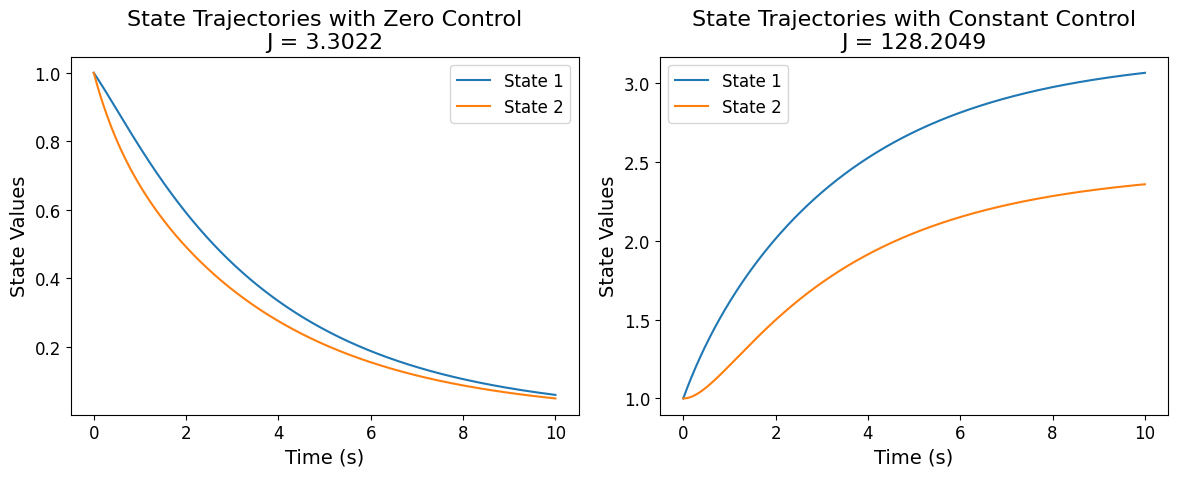

In [6]:
# plottting the simulation results

def u_zero(t, x):
    return torch.zeros(x.shape[0], 1, 1), torch.zeros(x.shape[0], 1)  # Example zero control input
time_grid_zero, x_zero, J_zero, log_p_zero = simulate_system(f, ell, Phi, x0, u_zero, T, dt)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(time_grid_zero, x_zero[0, :, 0], label='State 1')
plt.plot(time_grid_zero, x_zero[0, :, 1], label='State 2')
plt.title(f'State Trajectories with Zero Control\nJ = {J_zero[0].item():.4f}')
plt.xlabel('Time (s)')
plt.ylabel('State Values')
plt.legend()

def u_const(t, x):
    return torch.ones(x.shape[0], 1, 1), torch.zeros(x.shape[0], 1)  # Example constant control input
time_grid_const, x_const, J_const, log_p_const = simulate_system(f, ell, Phi, x0, u_const, T, dt)

plt.subplot(1, 2, 2)
plt.plot(time_grid_const, x_const[0, :, 0], label='State 1')
plt.plot(time_grid_const, x_const[0, :, 1], label='State 2')
plt.title(f'State Trajectories with Constant Control\nJ = {J_const[0].item():.4f}')
plt.xlabel('Time (s)')
plt.ylabel('State Values')
plt.legend()

plt.tight_layout()
plt.show()

## 策略学习

一种常见做法是将确定性策略推广为随机策略$\pi_{\theta}(t,x)$。例如，在连续控制中，常将策略建模为高斯分布
\begin{align*}
    \pi_{\theta}(x,t) \sim \mathcal N\bigl(\mu_{\theta}(x,t),\Sigma_{\theta}(x,t)\bigr).
\end{align*}
其中，$\mu_{\theta}(x,t)$表示策略的均值函数，$\Sigma_{\theta}(x,t)$表示策略的协方差矩阵；在常见设定下，它通常取为对角矩阵。
在离散化后的时间网格上，记整段状态序列与控制序列为
\begin{align*}
    x=\left(x_0,x_1,\dots,x_N\right) && u=(u_0,u_1,\dots,u_{N-1})
\end{align*}
在给定初始状态$x_0$的条件下，整段控制序列的条件概率密度可写为
\begin{align*}
    p_{\theta}(u\mid x_0)
    &=\prod_{k=0}^{N-1}\frac{1}{\sqrt{(2\pi)^m\det \Sigma_{\theta}(x_k,t_k)}} \\
    &\quad \times \exp\!\left(
        -\frac{1}{2}\bigl(u_k-\mu_{\theta}(x_k,t_k)\bigr)^\top
        \Sigma_{\theta}(x_k,t_k)^{-1}
        \bigl(u_k-\mu_{\theta}(x_k,t_k)\bigr)
    \right).
\end{align*}
$x_0$与$u$的联合分布可写为
\begin{align*}
    p_{\theta}(x_0,u)=p_{X_0}(x_0)\,p_{\theta}(u\mid x_0),
    \qquad
    p_{X_0}(x_0)=\frac{1}{\mathcal X_0 \text{的测度}},\ \ x_0\in\mathcal X_0.
\end{align*}
于是，总体目标函数可写为
\begin{align*}
    J^{\mathrm{tot}}(\theta)
    &= \mathbb{E}_{(x_0,u)\sim p_{\theta}(x_0,u)}\bigl[J(x_0,u)\bigr].
\end{align*}
其导数为
\begin{align*}
    \nabla_{\theta}J^{\mathrm{tot}}(\theta)
    =\mathbb{E}_{(x_0,u)\sim p_{\theta}(x_0,u)}
    \left[
        \left(J(x_0,u)-b\right)\nabla_{\theta}\log p_{\theta}(x_0,u)
    \right].
\end{align*}

In [83]:
import torch.nn as nn
import torch.distributions as D

# 定义高斯随机策略，输入 (t, x)，输出 u ~ N(mu(t,x), sigma(t,x)^2)
class GaussianPolicy(nn.Module):
    def __init__(self, state_dim, control_dim, hidden_dim=32):
        super().__init__()
        self.mu_net = nn.Sequential(
            nn.Linear(state_dim + 1, hidden_dim),  # +1 for time
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, control_dim),
        )
        # log 标准差也用神经网络建模: log_sigma = log_sigma_net(t, x)
        self.log_std_net = nn.Sequential(
            nn.Linear(state_dim + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, control_dim),
        )

    def _build_input(self, t, x):
        if isinstance(t, (float, int)):
            t = torch.ones(x.size(0), 1, dtype=x.dtype, device=x.device) * t
        elif t.dim() == 1:
            t = t.unsqueeze(-1)
        x_flat = x.squeeze(-1)
        return torch.cat([t, x_flat], dim=-1)          # (batch, state_dim+1)

    def forward(self, t, x):
        # t: float/int, x: (batch_size, state_dim, 1)
        # 返回: u (batch_size, control_dim, 1), log_p (batch_size, 1)
        inp = self._build_input(t, x)                  # (batch, state_dim+1)
        mu = self.mu_net(inp)                           # (batch, control_dim)
        log_std = self.log_std_net(inp).clamp(-5, 2)   # 限制范围防止数值问题
        std = log_std.exp()                             # (batch, control_dim)
        dist = D.Normal(mu, std)
        u_sample = dist.sample()                        # REINFORCE 必须用 sample() 而非 rsample()
        log_p = dist.log_prob(u_sample).sum(dim=-1, keepdim=True)  # (batch, 1)
        return u_sample.unsqueeze(-1), log_p            # (batch, control_dim, 1), (batch, 1)

    def deterministic(self, t, x):
        """用均值做确定性推理（评估用）"""
        inp = self._build_input(t, x)
        mu = self.mu_net(inp)
        return mu.unsqueeze(-1), torch.zeros(x.size(0), 1)  # log_p=0 for deterministic
    
state_dim = A.shape[0]
control_dim = B.shape[1]
policy = GaussianPolicy(state_dim, control_dim, hidden_dim=32)  # 构建神经网络控制器
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)
baseline = None  # 用于 REINFORCE 的移动平均 baseline

num_epochs = 300
loss_history = []
batch_size = 100

start_time = time.perf_counter()

# REINFORCE 训练
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # 采样初始状态
    x0_batch = 1 + torch.rand(batch_size, state_dim, 1)

    # 前向仿真（不需要对 J 反向传播，梯度通过 log_p 传递）
    time_grid_train, x_train, J_train, log_p_train = simulate_system(
        f, ell, Phi, x0_batch, policy, T, dt
    )

    J_scalar = J_train.squeeze()  # (batch_size,)

    # 更新移动平均 baseline
    # if baseline is None:
    #     baseline = J_scalar.mean().item()
    # else:
    #     baseline = 0.9 * baseline + 0.1 * J_scalar.mean().item()
    baseline = J_scalar.mean().item()

    # REINFORCE 梯度: E[ (J - b) * log_p ]
    advantage = (J_scalar - baseline).detach()
    log_p_total = log_p_train.squeeze()  # (batch_size,)
    loss = (advantage * log_p_total).mean()

    loss.backward()
    optimizer.step()

    loss_history.append(J_scalar.mean().item())

    if epoch % 30 == 0:
        print(f"epoch={epoch:4d}, J={J_scalar.mean().item():.4f}")

elapsed = time.perf_counter() - start_time

print("-" * 50)
print(f"final cost J = {loss_history[-1]:.4f}")
print(f"elapsed time  = {elapsed:.4f} s")

# 存储结果
# torch.save({
#     'policy_state_dict': policy.state_dict(),
#     'loss_history': loss_history,
# }, 'results/reinforce_results.pth')

epoch=   0, J=67.6387
epoch=  30, J=11.9905
epoch=  60, J=8.6095
epoch=  90, J=6.4455
epoch= 120, J=5.2829
epoch= 150, J=5.1048
epoch= 180, J=3.9592
epoch= 210, J=3.8446
epoch= 240, J=4.0058
epoch= 270, J=3.7246
--------------------------------------------------
final cost J = 7.3123
elapsed time  = 167.4122 s


策略梯度算法收敛得很慢。接下来，我们用一组训练好的参数将结果和理论最优控制进行比较（如下）。可以看到策略梯度方法大致可以还原出理论上的最优控制结果。

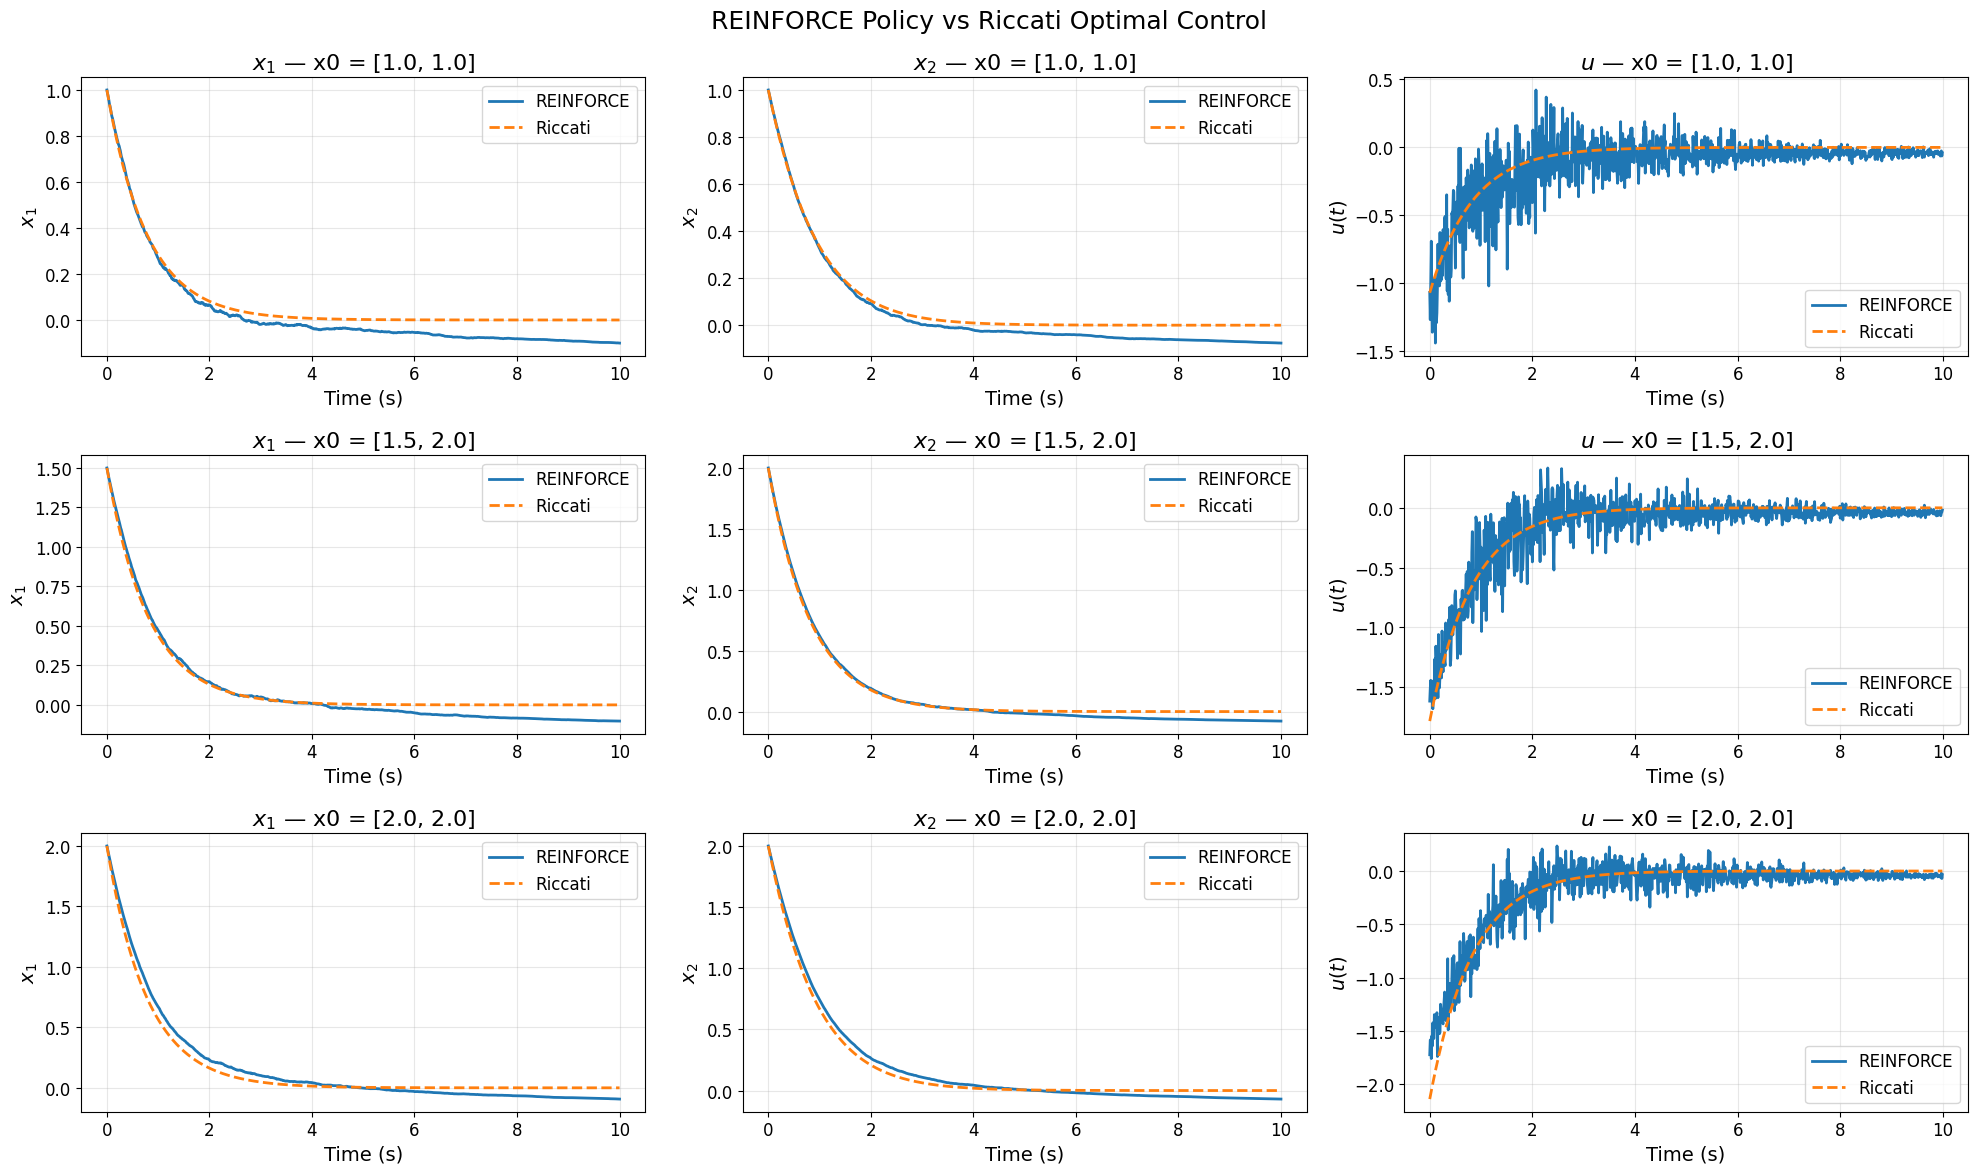

初始条件                  REINFORCE J    Riccati J         相对误差
------------------------------------------------------------
x0 = [1.0, 1.0]            1.5893       1.3452      18.14 %
x0 = [1.5, 2.0]            4.1315       3.9239       5.29 %
x0 = [2.0, 2.0]            5.6101       5.3809       4.26 %


In [84]:
# 读取结果 
saved_result = torch.load('results/reinforce_results.pth')
policy.load_state_dict(saved_result['policy_state_dict'])


X0 = torch.tensor([[[1.0], [1.0]],
                   [[1.5], [2.]],
                   [[2.], [2]]])  # (3, state_dim, 1)

# 用随机策略进行仿真
with torch.no_grad():
    time_grid_nn, x_nn, J_nn, _ = simulate_system(f, ell, Phi, X0, policy, T, dt)

# 基于Ricatti方程的最优控制
P = torch.load("Results/riccati_solution.pt")
def u_riccati(t, x):
    position = int(t // dt)
    u_val = -torch.linalg.inv(R) @ B.transpose(-2, -1) @ P[position] @ x
    return u_val, torch.zeros(x.size(0), 1)
time_grid_riccati, x_riccati, J_riccati, _ = simulate_system(f, ell, Phi, X0, u_riccati, T, dt)

# 计算两组初始条件下的控制输入
num_steps = int(T / dt)
control_time = time_grid_nn[:-1]
n_ic = X0.shape[0]
u_nn_traj = torch.zeros(n_ic, num_steps, control_dim)
u_ric_traj = torch.zeros(n_ic, num_steps, control_dim)
with torch.no_grad():
    for i in range(n_ic):
        for k in range(num_steps):
            t_k = k * dt
            x_k_nn = x_nn[i, k].unsqueeze(0).unsqueeze(-1)
            u_nn_traj[i, k] = policy.deterministic(t_k, x_k_nn)[0].squeeze()
            x_k_ric = x_riccati[i, k].unsqueeze(0).unsqueeze(-1)
            u_ric_traj[i, k] = u_riccati(t_k, x_k_ric)[0].squeeze()
            u_nn_traj[i, k] = policy(t_k, x_k_nn)[0].squeeze()
# 绘制比较图
labels_x0 = [f"x0 = {X0[i].squeeze(-1).tolist()}" for i in range(n_ic)]
fig, axes = plt.subplots(n_ic, 3, figsize=(20, 4 * n_ic))

for i in range(n_ic):
    axes[i, 0].plot(time_grid_nn, x_nn[i, :, 0], label='REINFORCE', linewidth=2)
    axes[i, 0].plot(time_grid_riccati, x_riccati[i, :, 0], '--', label='Riccati', linewidth=2)
    axes[i, 0].set_title(f'$x_1$ — {labels_x0[i]}')
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('$x_1$')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(time_grid_nn, x_nn[i, :, 1], label='REINFORCE', linewidth=2)
    axes[i, 1].plot(time_grid_riccati, x_riccati[i, :, 1], '--', label='Riccati', linewidth=2)
    axes[i, 1].set_title(f'$x_2$ — {labels_x0[i]}')
    axes[i, 1].set_xlabel('Time (s)')
    axes[i, 1].set_ylabel('$x_2$')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

    axes[i, 2].plot(control_time, u_nn_traj[i, :, 0], label='REINFORCE', linewidth=2)
    axes[i, 2].plot(control_time, u_ric_traj[i, :, 0], '--', label='Riccati', linewidth=2)
    axes[i, 2].set_title(f'$u$ — {labels_x0[i]}')
    axes[i, 2].set_xlabel('Time (s)')
    axes[i, 2].set_ylabel('$u(t)$')
    axes[i, 2].legend()
    axes[i, 2].grid(True, alpha=0.3)

plt.suptitle('REINFORCE Policy vs Riccati Optimal Control', fontsize=18)
plt.tight_layout()
plt.show()

# 打印代价对比
print(f"{'初始条件':<20} {'REINFORCE J':>12} {'Riccati J':>12} {'相对误差':>12}")
print("-" * 60)
for i in range(n_ic):
    j_nn = J_nn[i].item()
    j_ric = J_riccati[i].item()
    rel_err = abs(j_nn - j_ric) / abs(j_ric) * 100
    print(f"{labels_x0[i]:<20} {j_nn:>12.4f} {j_ric:>12.4f} {rel_err:>10.2f} %")